# Previsão de Preços de Ações da Amazon

**Projeto Integrador IV**  
**Modelos:** LSTM, Regressão Linear Regularizada (Lasso/Ridge) e SVR  
**Objetivo:** prever o preço futuro imediato das ações da Amazon e o preço em um horizonte de 90 períodos.

Este notebook foi organizado para publicação no GitHub.  
A estrutura segue a lógica do CRISP-DM: compreensão do negócio, compreensão dos dados, preparação, modelagem, avaliação e conclusão.

## 1. Configuração do ambiente

Execute esta célula apenas se estiver em um ambiente novo, como Google Colab.

In [ ]:
# Instalações necessárias para ambientes novos
# Em ambiente local, você também pode instalar via requirements.txt.
!pip install -q kagglehub yfinance

In [ ]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

import yfinance as yf

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

DATA_DIR = Path('datasets')
DATA_DIR.mkdir(exist_ok=True)

TICKER_AMZN = 'AMZN'
DATA_INICIO = '1997-05-15'
DATA_FIM = '2025-02-22'

## 2. Coleta dos dados

A base principal é carregada do Kaggle.  
Caso os arquivos já existam na pasta `datasets/`, o notebook usa os arquivos locais para manter o mesmo fluxo de execução.

In [ ]:
def carregar_base_amazon():
    caminho_csv = DATA_DIR / 'AMZN_stock_data.csv'

    if caminho_csv.exists():
        print(f'Base principal encontrada em: {caminho_csv}')
        df_base = pd.read_csv(caminho_csv)
    else:
        import kagglehub

        path = kagglehub.dataset_download('meharshanali/amazon-stocks-2025')
        arquivo_origem = Path(path) / 'AMZN_stock_data.csv'

        df_base = pd.read_csv(arquivo_origem)
        df_base.to_csv(caminho_csv, index=False)

        print(f'Base principal baixada e salva em: {caminho_csv}')

    df_base['Date'] = pd.to_datetime(df_base['Date'], utc=True).dt.tz_localize(None).dt.normalize()
    df_base = df_base.sort_values('Date').reset_index(drop=True)

    return df_base


df = carregar_base_amazon()

display(df.head())
display(df.tail())
print(df.shape)

100%|██████████| 162k/162k [00:00<00:00, 327kB/s]

Extracting files...


Base principal baixada e salva em: datasets/AMZN_stock_data.csv


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.000000,0.000000
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.000000,0.000000
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.000000,0.000000
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.000000,0.000000
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.000000,0.000000


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
6982,2025-02-14,229.199997,229.889999,227.229996,228.679993,27031100,0.000000,0.000000
6983,2025-02-18,228.820007,229.300003,223.720001,226.649994,42975100,0.000000,0.000000
6984,2025-02-19,225.520004,226.830002,223.710007,226.630005,28566700,0.000000,0.000000
6985,2025-02-20,224.779999,225.130005,221.809998,222.880005,30001700,0.000000,0.000000
6986,2025-02-21,223.279999,223.309998,214.740005,216.580002,55161000,0.000000,0.000000


(6987, 8)


## 3. Compreensão dos dados

In [ ]:
print('Formato da base:', df.shape)
print('\nTipos de dados:')
display(df.dtypes)

print('\nValores nulos:')
display(df.isnull().sum())

print('\nDuplicados:', df.duplicated().sum())

print(f"Data mais antiga: {df['Date'].min().date()}")
print(f"Data mais recente: {df['Date'].max().date()}")

display(df.describe().round(2))

Formato da base: (6987, 8)

Tipos de dados:


,0
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Dividends,float64
Stock Splits,float64



Valores nulos:


,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0



Duplicados: 0
Data mais antiga: 1997-05-15
Data mais recente: 2025-02-21


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,6987,6987.000000,6987.000000,6987.000000,6987.000000,6987.000000,6987.000000,6987.000000
mean,2011-04-02 17:34:23.546586368,40.690000,41.170000,40.180000,40.690000,136055187.510000,0.000000,0.000000
min,1997-05-15 00:00:00,0.070000,0.070000,0.070000,0.070000,9744000.000000,0.000000,0.000000
25%,2004-04-26 12:00:00,2.100000,2.150000,2.060000,2.110000,62989000.000000,0.000000,0.000000
50%,2011-04-01 00:00:00,9.040000,9.160000,8.930000,9.020000,100536000.000000,0.000000,0.000000
75%,2018-03-12 12:00:00,72.790000,73.640000,71.500000,73.010000,155507000.000000,0.000000,0.000000
max,2025-02-21 00:00:00,239.020000,242.520000,238.030000,242.060000,2086584000.000000,0.000000,20.000000
std,NaN,58.140000,58.790000,57.440000,58.130000,137573539.820000,0.000000,0.240000


### Dicionário de variáveis

- **Date:** data da negociação.
- **Open:** preço de abertura.
- **High:** preço máximo do dia.
- **Low:** preço mínimo do dia.
- **Close:** preço de fechamento.
- **Volume:** quantidade de ações negociadas.
- **Dividends:** dividendos pagos.
- **Stock Splits:** eventos de desdobramento das ações.

## 4. Análise exploratória

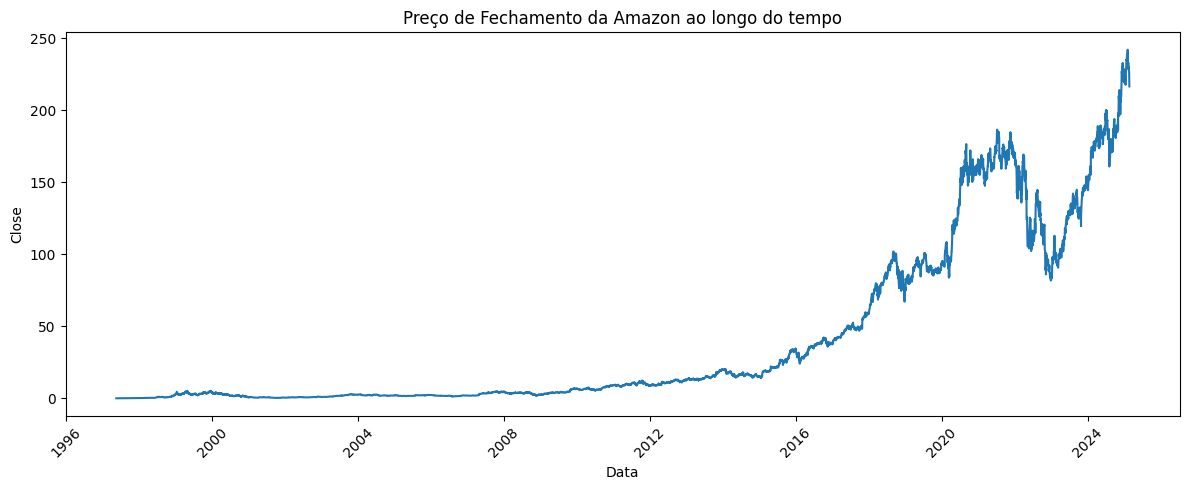

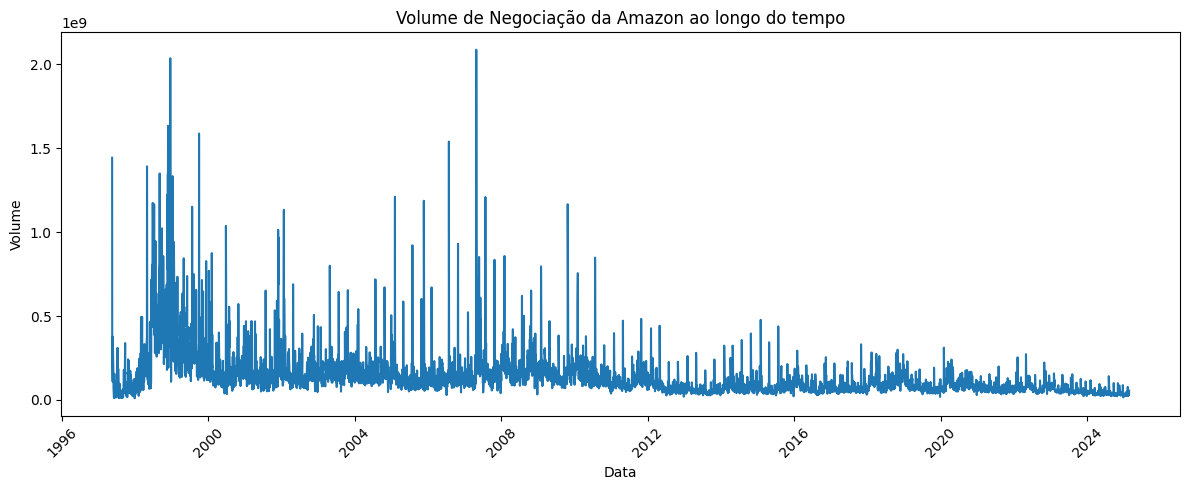

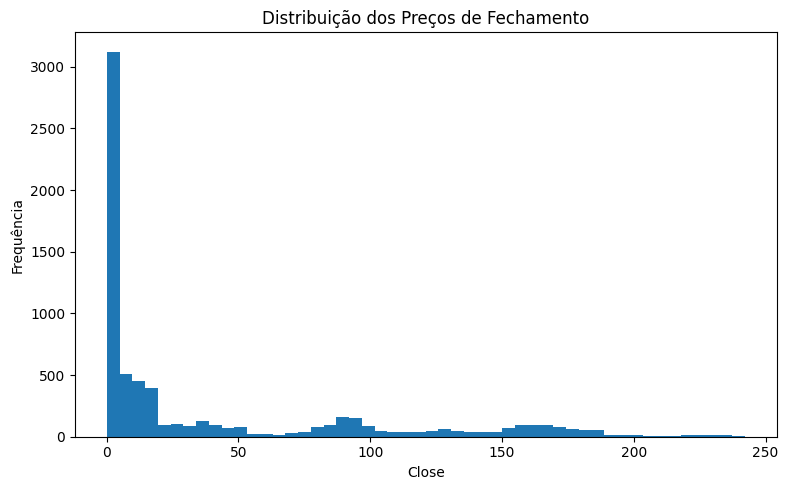

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'])
plt.title('Preço de Fechamento da Amazon ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Close')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Volume'])
plt.title('Volume de Negociação da Amazon ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['Close'], bins=50)
plt.title('Distribuição dos Preços de Fechamento')
plt.xlabel('Close')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

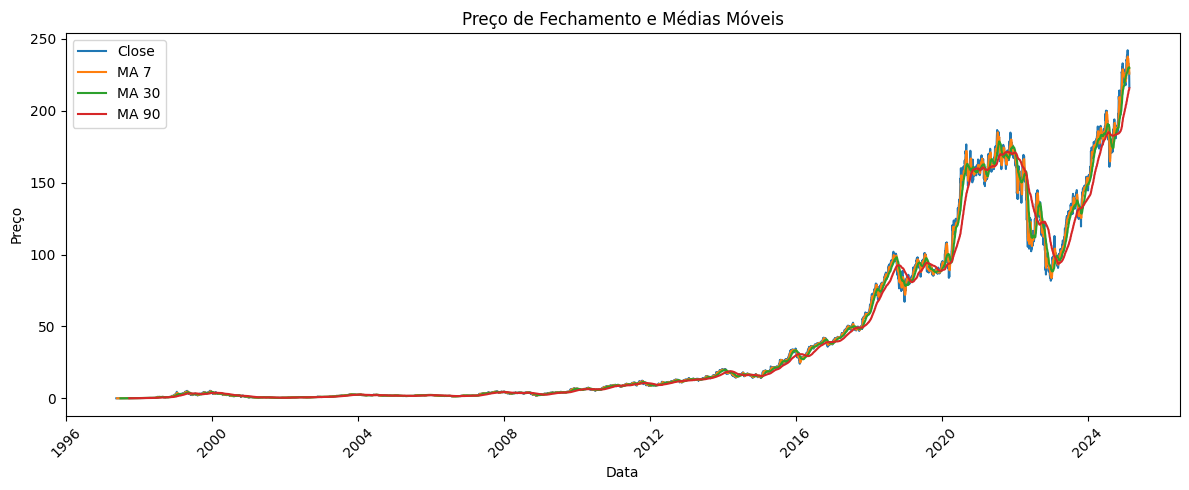

In [ ]:
df_eda = df.copy()
df_eda['MA_7'] = df_eda['Close'].rolling(window=7).mean()
df_eda['MA_30'] = df_eda['Close'].rolling(window=30).mean()
df_eda['MA_90'] = df_eda['Close'].rolling(window=90).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_eda['Date'], df_eda['Close'], label='Close')
plt.plot(df_eda['Date'], df_eda['MA_7'], label='MA 7')
plt.plot(df_eda['Date'], df_eda['MA_30'], label='MA 30')
plt.plot(df_eda['Date'], df_eda['MA_90'], label='MA 90')
plt.title('Preço de Fechamento e Médias Móveis')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Preparação dos dados e engenharia de atributos

Nesta etapa são criadas cinco bases usadas na modelagem:

- `df_original`: colunas originais em granularidade diária.
- `df_semanal`: colunas originais agrupadas por semana.
- `df_geral`: base diária enriquecida com variáveis financeiras.
- `df_geral_semanal`: base enriquecida agrupada por semana.
- `df_top10_corr`: 10 atributos com maior correlação absoluta com `Close`.

In [ ]:
def baixar_close_yfinance(ticker, inicio=DATA_INICIO, fim=DATA_FIM, nome='Ativo'):
    dados = yf.download(
        ticker,
        start=inicio,
        end=fim,
        progress=False,
        auto_adjust=False
    )

    if isinstance(dados.columns, pd.MultiIndex):
        close = dados['Close']
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
    else:
        close = dados['Close']

    out = close.reset_index()
    out.columns = ['Date', f'{nome}_Close']
    out['Date'] = pd.to_datetime(out['Date']).dt.tz_localize(None).dt.normalize()
    out[f'{nome}_Return'] = out[f'{nome}_Close'].pct_change()

    return out


def construir_datasets(df_base):
    df_original = df_base.copy()

    # Base semanal original
    df_semanal = (
        df_original
        .set_index('Date')
        .resample('W')
        .agg({
            'Open': 'mean',
            'High': 'mean',
            'Low': 'mean',
            'Close': 'mean',
            'Volume': 'mean',
            'Dividends': 'mean',
            'Stock Splits': 'mean'
        })
        .reset_index()
    )

    # Médias móveis da base semanal, preservando a lógica usada no projeto
    df_semanal['MA_7'] = df_semanal['Close'].rolling(window=7).mean()
    df_semanal['MA_30'] = df_semanal['Close'].rolling(window=30).mean()
    df_semanal['MA_90'] = df_semanal['Close'].rolling(window=90).mean()

    # Base geral enriquecida
    df_geral = df_original.copy()

    # DXY
    dxy = baixar_close_yfinance('DX-Y.NYB', inicio=DATA_INICIO, fim=DATA_FIM, nome='DXY')
    dxy = dxy.rename(columns={'DXY_Close': 'Close_DXY', 'DXY_Return': 'Close_DXY_Return'})
    df_geral = pd.merge(df_geral, dxy[['Date', 'Close_DXY', 'Close_DXY_Return']], on='Date', how='left')
    df_geral['Close_DXY_Change_Pct'] = df_geral['Close_DXY'].pct_change() * 100

    # Atributos financeiros internos
    df_geral['Open_Close_Change_Pct'] = (df_geral['Close'] - df_geral['Open']).pct_change() * 100
    df_geral['Daily_Average_Price'] = df_geral[['Open', 'High', 'Low', 'Close']].mean(axis=1)
    df_geral['Money_Moved_Daily'] = df_geral['Volume'] * df_geral['Daily_Average_Price']
    df_geral['Close_Price_Change_Pct'] = df_geral['Close'].pct_change() * 100

    # Retornos, volatilidade e indicadores técnicos
    df_geral['Log_Return'] = np.log(df_geral['Close'] / df_geral['Close'].shift(1))
    df_geral['Volatility_10'] = df_geral['Log_Return'].rolling(window=10).std()

    df_geral['MA_10'] = df_geral['Close'].rolling(window=10).mean()
    df_geral['MA_50'] = df_geral['Close'].rolling(window=50).mean()
    df_geral['Trend_Signal'] = np.where(df_geral['MA_10'] > df_geral['MA_50'], 1, -1)

    delta = df_geral['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss

    df_geral['RSI'] = 100 - (100 / (1 + rs))

    df_geral['Volume_MA_10'] = df_geral['Volume'].rolling(window=10).mean()
    df_geral['Volume_Spike'] = df_geral['Volume'] / df_geral['Volume_MA_10']
    df_geral['Range_to_Close'] = (df_geral['High'] - df_geral['Low']) / df_geral['Close']

    # Variáveis externas de mercado
    tickers = {
        'VIX': '^VIX',
        'NASDAQ': '^IXIC',
        'MSFT': 'MSFT',
        'GOOGL': 'GOOGL',
        'AAPL': 'AAPL',
        'US10Y': '^TNX'
    }

    for nome, ticker in tickers.items():
        ext = baixar_close_yfinance(ticker, inicio=DATA_INICIO, fim=DATA_FIM, nome=nome)
        df_geral = pd.merge(df_geral, ext, on='Date', how='left')

    df_geral = df_geral.sort_values('Date').ffill().fillna(0)

    # Base geral semanal
    agg_dict = {
        col: 'mean'
        for col in df_geral.columns
        if col != 'Date'
    }

    df_geral_semanal = (
        df_geral
        .set_index('Date')
        .resample('W')
        .agg(agg_dict)
        .reset_index()
    )

    # Top 10 correlações com Close
    corr_geral = df_geral.replace([np.inf, -np.inf], np.nan).corr(numeric_only=True)
    corr_close = corr_geral['Close'].drop('Close').abs().sort_values(ascending=False)

    top_10_features = corr_close.head(10).index.tolist()
    df_top10_corr = df_geral[['Date', 'Close'] + top_10_features].copy()

    return {
        'df_original': df_original,
        'df_semanal': df_semanal,
        'df_geral': df_geral,
        'df_geral_semanal': df_geral_semanal,
        'df_top10_corr': df_top10_corr
    }


datasets = construir_datasets(df)

for nome, dataset in datasets.items():
    dataset.to_csv(DATA_DIR / f'{nome}.csv', index=False)
    print(f'{nome}: {dataset.shape}')

df_original: (6987, 8)
df_semanal: (1450, 11)
df_geral: (6987, 36)
df_geral_semanal: (1450, 36)
df_top10_corr: (6987, 12)


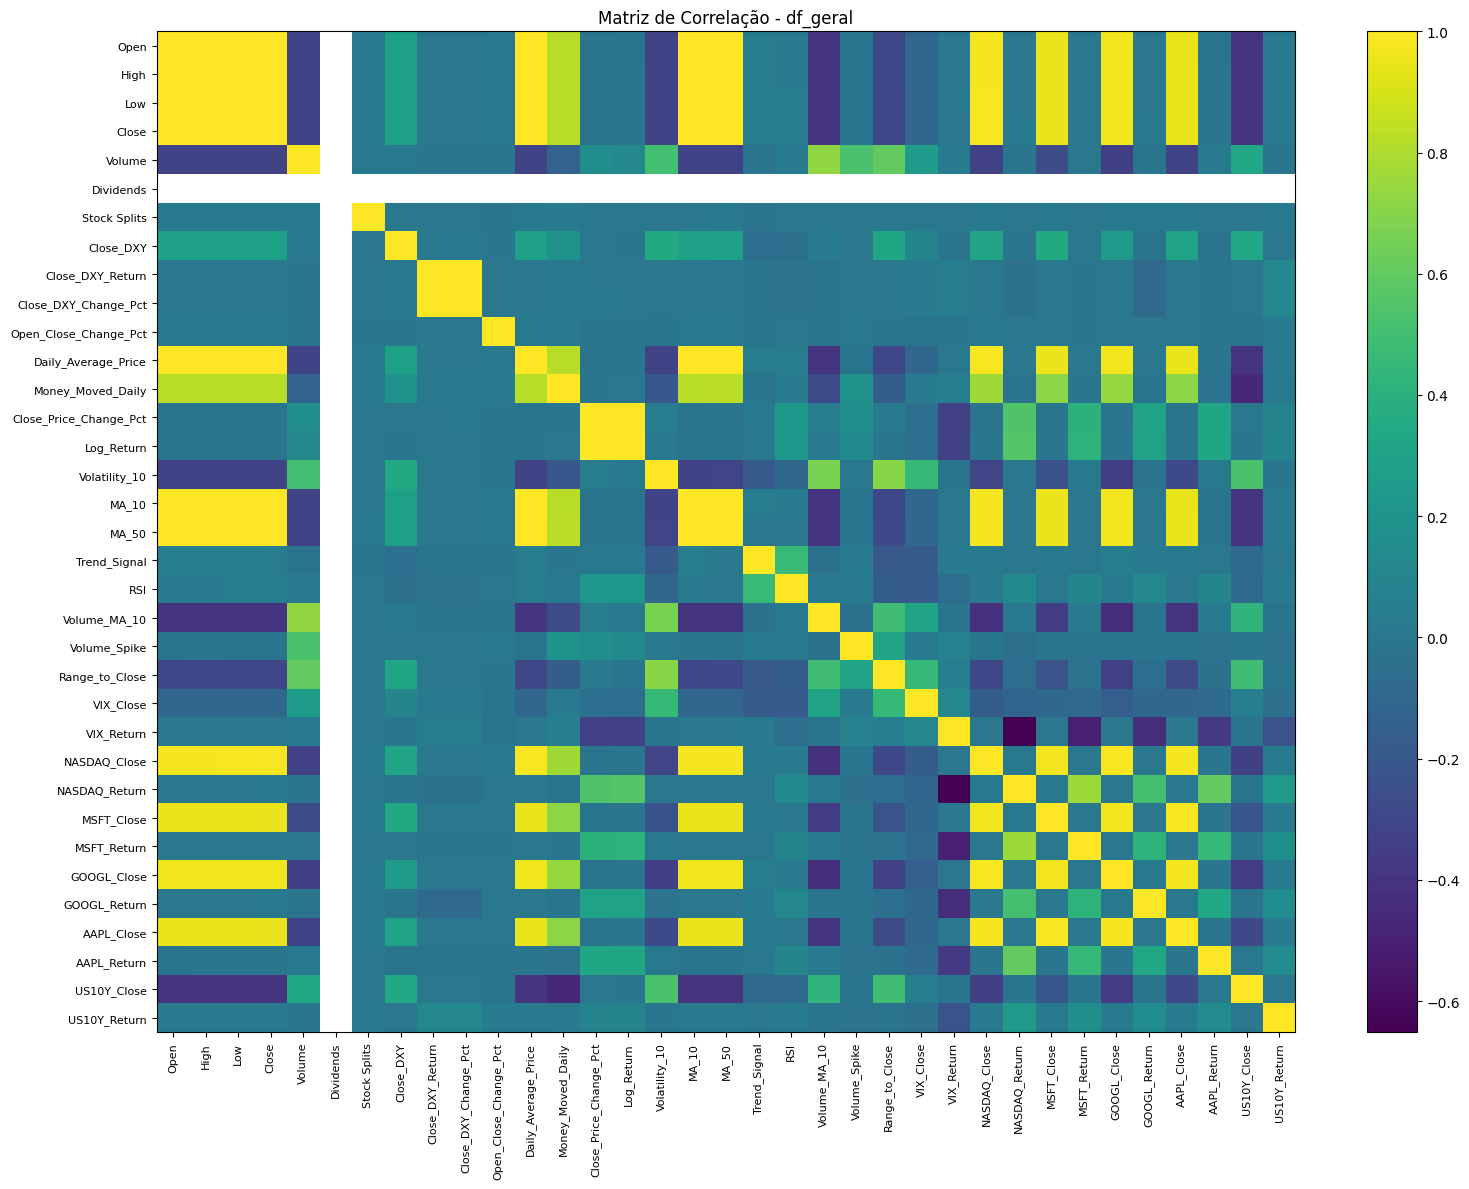

Top 10 features selecionadas para df_top10_corr:
['Daily_Average_Price', 'Low', 'High', 'Open', 'MA_10', 'MA_50', 'NASDAQ_Close', 'GOOGL_Close', 'MSFT_Close', 'AAPL_Close']


In [ ]:
# Visualização rápida das correlações da base geral
corr_geral = datasets['df_geral'].replace([np.inf, -np.inf], np.nan).corr(numeric_only=True)

plt.figure(figsize=(16, 12))
plt.imshow(corr_geral, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_geral.columns)), corr_geral.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr_geral.columns)), corr_geral.columns, fontsize=8)
plt.title('Matriz de Correlação - df_geral')
plt.tight_layout()
plt.show()

print('Top 10 features selecionadas para df_top10_corr:')
print([col for col in datasets['df_top10_corr'].columns if col not in ['Date', 'Close']])

## 6. Diagnóstico de qualidade dos datasets

In [ ]:
def diagnosticar_datasets(datasets):
    resumo = []

    for nome, df_temp in datasets.items():
        df_num = df_temp.select_dtypes(include=[np.number])

        nulos = int(df_num.isnull().sum().sum())

        df_inf = df_num.replace([np.inf, -np.inf], np.nan)
        qtd_inf = int((df_inf.isna().sum() - df_num.isna().sum()).sum())

        colunas_constantes = df_num.columns[df_num.nunique(dropna=True) <= 1].tolist()

        resumo.append({
            'Dataset': nome,
            'Linhas': df_temp.shape[0],
            'Colunas': df_temp.shape[1],
            'Colunas_Numéricas': df_num.shape[1],
            'Tem_Close': 'Close' in df_temp.columns,
            'Nulos': nulos,
            'Infinitos': qtd_inf,
            'Colunas_Constantes': colunas_constantes
        })

    return pd.DataFrame(resumo)


df_diagnostico = diagnosticar_datasets(datasets)
display(df_diagnostico)

,Dataset,Linhas,Colunas,Colunas_Numéricas,Tem_Close,Nulos,Infinitos,Colunas_Constantes
0,df_original,6987,8,7,True,0,0,[Dividends]
1,df_semanal,1450,11,10,True,124,0,[Dividends]
2,df_geral,6987,36,35,True,0,33,[Dividends]
3,df_geral_semanal,1450,36,35,True,0,33,[Dividends]
4,df_top10_corr,6987,12,11,True,0,0,[]


## 7. Modelagem — Regressão Linear Regularizada: Lasso e Ridge

Os modelos Lasso e Ridge são usados para previsão futura.  
A variável-alvo é criada por deslocamento temporal:

- `horizonte=1`: previsão do próximo período.
- `horizonte=90`: previsão de 90 períodos à frente.

Para evitar vazamento de informação, `Close(t)` é removido das variáveis explicativas quando o alvo é `Close(t+h)`.

In [ ]:
def preparar_base_modelo_futuro(df_input, horizonte, target_col='Close'):
    df_model = df_input.copy()
    df_model.columns = df_model.columns.str.strip()

    if 'Date' in df_model.columns:
        df_model['Date'] = pd.to_datetime(df_model['Date'], errors='coerce')
        df_model = df_model.sort_values('Date').reset_index(drop=True)

    target_name = f'Target_Close_{horizonte}'
    df_model[target_name] = df_model[target_col].shift(-horizonte)

    df_model = df_model.select_dtypes(include=[np.number])
    df_model = df_model.replace([np.inf, -np.inf], np.nan)
    df_model = df_model.dropna()

    colunas_features = [col for col in df_model.columns if col not in [target_col, target_name]]
    colunas_constantes = df_model[colunas_features].columns[
        df_model[colunas_features].nunique(dropna=True) <= 1
    ].tolist()

    df_model = df_model.drop(columns=colunas_constantes)

    X = df_model.drop(columns=[target_name, target_col])
    y = df_model[target_name]

    return X, y, colunas_constantes


def executar_regressao_regularizada(df_input, nome_dataset, horizonte=1, tipo='lasso'):
    X, y, colunas_constantes = preparar_base_modelo_futuro(df_input, horizonte=horizonte)

    split_idx = int(len(X) * 0.8)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if tipo == 'lasso':
        modelo = Lasso(alpha=0.01, max_iter=100000, tol=1e-4, random_state=42)
    elif tipo == 'ridge':
        modelo = Ridge(alpha=1.0, random_state=42)
    else:
        raise ValueError("tipo deve ser 'lasso' ou 'ridge'")

    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    ultimo_registro = X.iloc[[-1]]
    ultimo_registro_scaled = scaler.transform(ultimo_registro)
    previsao_futura = float(modelo.predict(ultimo_registro_scaled)[0])

    coeficientes = pd.DataFrame({
        'Feature': X.columns,
        'Coeficiente': modelo.coef_
    })

    coeficientes['Coeficiente_abs'] = coeficientes['Coeficiente'].abs()
    coeficientes = coeficientes.sort_values('Coeficiente_abs', ascending=False)

    resultado = {
        'Modelo': tipo.upper(),
        'Dataset': nome_dataset,
        'Horizonte': horizonte,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Previsao_Futura': previsao_futura,
        'Features': X.shape[1],
        'Linhas_usadas': len(X),
        'Colunas_constantes_removidas': colunas_constantes
    }

    return resultado, modelo, scaler, coeficientes, y_test, y_pred


def executar_modelos_lineares(datasets, tipo, horizonte):
    resultados = []
    artefatos = {}

    for nome, df_temp in datasets.items():
        resultado, modelo, scaler, coef, y_test, y_pred = executar_regressao_regularizada(
            df_temp,
            nome_dataset=nome,
            horizonte=horizonte,
            tipo=tipo
        )

        resultados.append(resultado)
        artefatos[nome] = {
            'modelo': modelo,
            'scaler': scaler,
            'coeficientes': coef,
            'y_test': y_test,
            'y_pred': y_pred
        }

    df_resultados = pd.DataFrame(resultados).sort_values('RMSE').reset_index(drop=True)
    return df_resultados, artefatos

In [ ]:
# Lasso
df_resultados_lasso_d1, artefatos_lasso_d1 = executar_modelos_lineares(datasets, tipo='lasso', horizonte=1)
df_resultados_lasso_d90, artefatos_lasso_d90 = executar_modelos_lineares(datasets, tipo='lasso', horizonte=90)

print('===== RESULTADOS LASSO - PRÓXIMO PERÍODO =====')
display(df_resultados_lasso_d1)

print('===== RESULTADOS LASSO - 90 PERÍODOS =====')
display(df_resultados_lasso_d90)

# Ridge
df_resultados_ridge_d1, artefatos_ridge_d1 = executar_modelos_lineares(datasets, tipo='ridge', horizonte=1)
df_resultados_ridge_d90, artefatos_ridge_d90 = executar_modelos_lineares(datasets, tipo='ridge', horizonte=90)

print('===== RESULTADOS RIDGE - PRÓXIMO PERÍODO =====')
display(df_resultados_ridge_d1)

print('===== RESULTADOS RIDGE - 90 PERÍODOS =====')
display(df_resultados_ridge_d90)

===== RESULTADOS LASSO - PRÓXIMO PERÍODO =====


,Modelo,Dataset,Horizonte,MAE,RMSE,R2,Previsao_Futura,Features,Linhas_usadas,Colunas_constantes_removidas
0,LASSO,df_top10_corr,1,2.385942,3.251299,0.992078,223.852128,10,6986,[]
1,LASSO,df_original,1,2.401985,3.267375,0.991999,223.538453,5,6986,[Dividends]
2,LASSO,df_geral,1,2.436919,3.325235,0.991675,224.489660,33,6953,[Dividends]
3,LASSO,df_semanal,1,4.303103,5.717260,0.972942,230.775004,8,1360,[Dividends]
4,LASSO,df_geral_semanal,1,4.300030,5.795262,0.974388,232.465360,33,1416,[Dividends]


===== RESULTADOS LASSO - 90 PERÍODOS =====


,Modelo,Dataset,Horizonte,MAE,RMSE,R2,Previsao_Futura,Features,Linhas_usadas,Colunas_constantes_removidas
0,LASSO,df_original,90,20.790093,26.165059,0.478435,202.453056,5,6897,[Dividends]
1,LASSO,df_geral,90,24.159877,31.893069,0.220614,223.823871,33,6864,[Dividends]
2,LASSO,df_top10_corr,90,28.872251,36.851610,-0.034612,237.959956,10,6897,[]
3,LASSO,df_geral_semanal,90,65.375113,86.504557,-5.404096,176.522673,33,1327,[Dividends]
4,LASSO,df_semanal,90,124.133134,155.286842,-21.159134,278.228454,8,1271,[Dividends]


===== RESULTADOS RIDGE - PRÓXIMO PERÍODO =====


,Modelo,Dataset,Horizonte,MAE,RMSE,R2,Previsao_Futura,Features,Linhas_usadas,Colunas_constantes_removidas
0,RIDGE,df_top10_corr,1,2.416662,3.277331,0.991951,224.792962,10,6986,[]
1,RIDGE,df_original,1,2.415794,3.282235,0.991926,223.845060,5,6986,[Dividends]
2,RIDGE,df_geral,1,2.436112,3.304083,0.991780,225.337634,33,6953,[Dividends]
3,RIDGE,df_geral_semanal,1,4.204502,5.658719,0.975580,233.128940,33,1416,[Dividends]
4,RIDGE,df_semanal,1,4.394348,5.839129,0.971776,230.724750,8,1360,[Dividends]


===== RESULTADOS RIDGE - 90 PERÍODOS =====


,Modelo,Dataset,Horizonte,MAE,RMSE,R2,Previsao_Futura,Features,Linhas_usadas,Colunas_constantes_removidas
0,RIDGE,df_original,90,20.766847,26.123928,0.480074,202.955164,5,6897,[Dividends]
1,RIDGE,df_geral,90,25.588047,33.772220,0.126065,228.943105,33,6864,[Dividends]
2,RIDGE,df_top10_corr,90,31.052498,39.004496,-0.159028,242.554786,10,6897,[]
3,RIDGE,df_geral_semanal,90,64.440781,84.998178,-5.182998,175.730832,33,1327,[Dividends]
4,RIDGE,df_semanal,90,122.190768,153.073025,-20.531822,276.238021,8,1271,[Dividends]


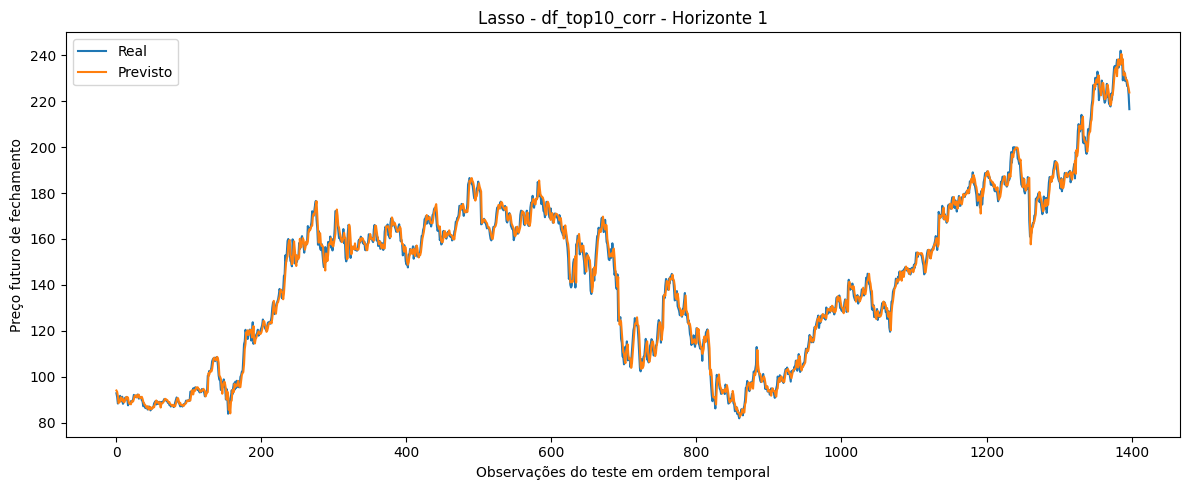

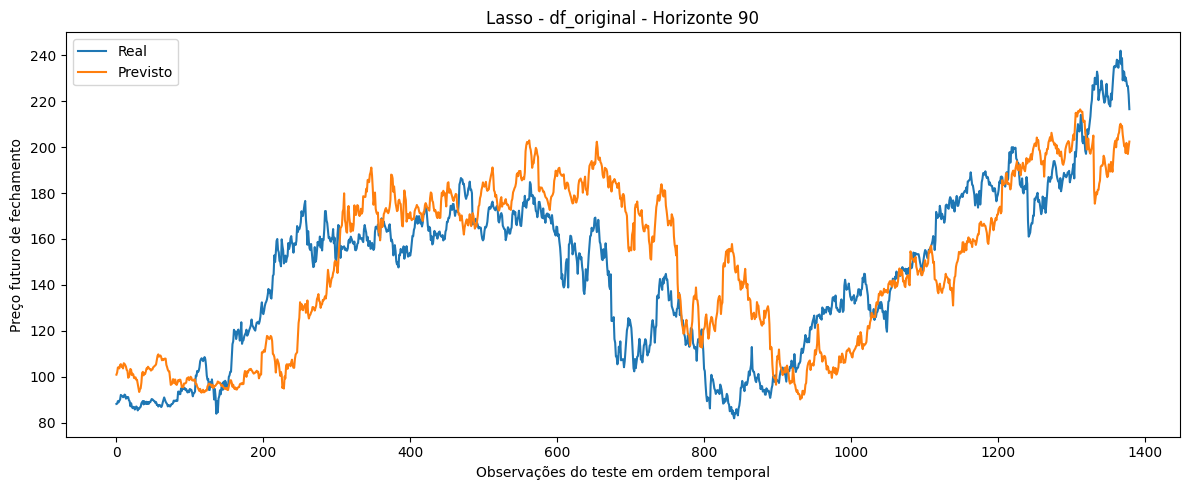

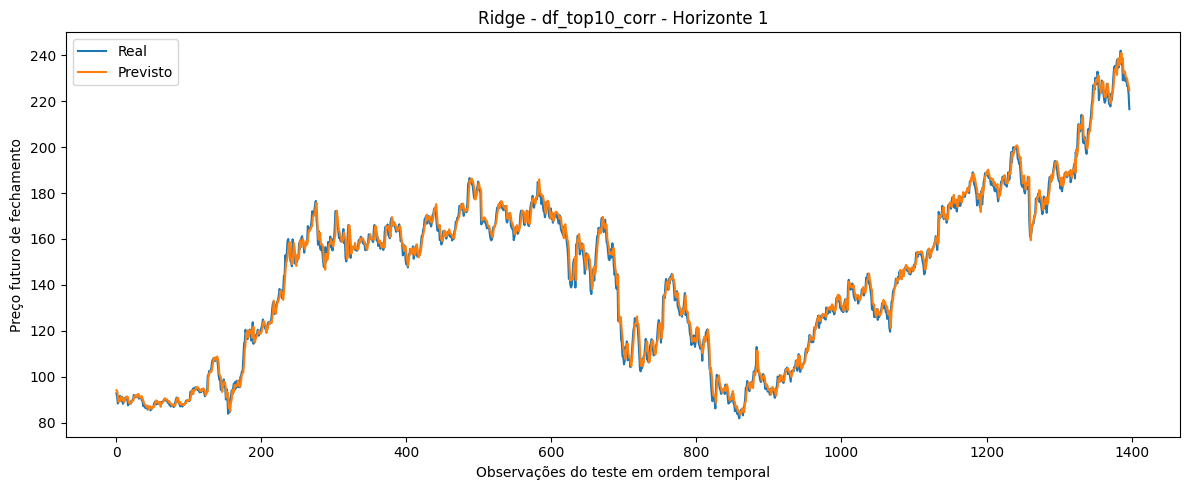

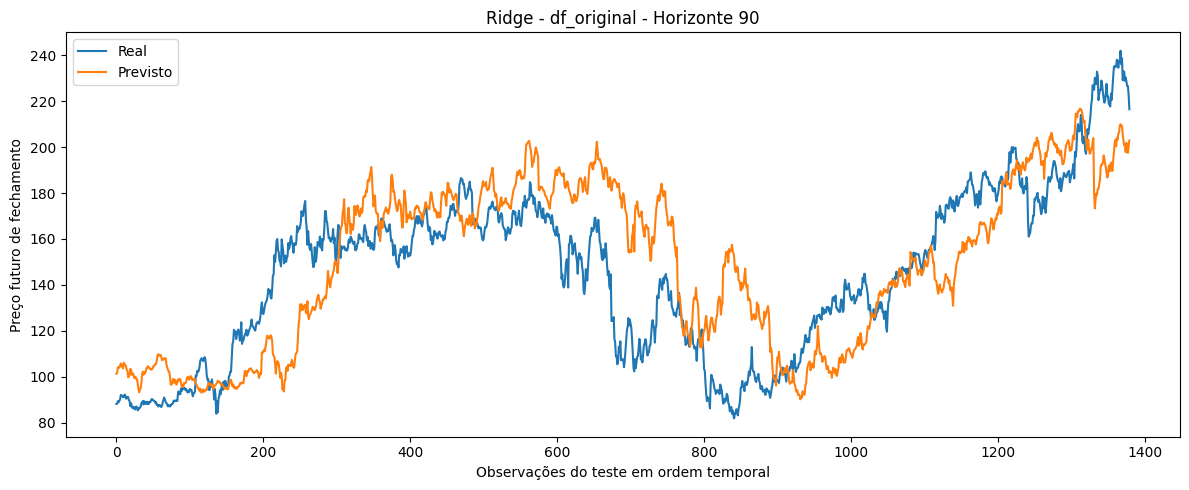

In [ ]:
def plotar_resultados_modelo(df_resultados, artefatos, titulo):
    melhor = df_resultados.iloc[0]
    dataset = melhor['Dataset']

    y_test = artefatos[dataset]['y_test']
    y_pred = artefatos[dataset]['y_pred']

    plt.figure(figsize=(12, 5))
    plt.plot(y_test.values, label='Real')
    plt.plot(y_pred, label='Previsto')
    plt.title(f"{titulo} - {dataset} - Horizonte {int(melhor['Horizonte'])}")
    plt.xlabel('Observações do teste em ordem temporal')
    plt.ylabel('Preço futuro de fechamento')
    plt.legend()
    plt.tight_layout()
    plt.show()


plotar_resultados_modelo(df_resultados_lasso_d1, artefatos_lasso_d1, 'Lasso')
plotar_resultados_modelo(df_resultados_lasso_d90, artefatos_lasso_d90, 'Lasso')
plotar_resultados_modelo(df_resultados_ridge_d1, artefatos_ridge_d1, 'Ridge')
plotar_resultados_modelo(df_resultados_ridge_d90, artefatos_ridge_d90, 'Ridge')

In [ ]:
# Coeficientes dos melhores modelos Lasso e Ridge
melhor_lasso_d1 = df_resultados_lasso_d1.iloc[0]['Dataset']
melhor_lasso_d90 = df_resultados_lasso_d90.iloc[0]['Dataset']
melhor_ridge_d1 = df_resultados_ridge_d1.iloc[0]['Dataset']
melhor_ridge_d90 = df_resultados_ridge_d90.iloc[0]['Dataset']

print('Atributos selecionados pelo Lasso - próximo período')
display(
    artefatos_lasso_d1[melhor_lasso_d1]['coeficientes']
    .query('Coeficiente_abs > 0')
    [['Feature', 'Coeficiente']]
)

print('Atributos selecionados pelo Lasso - 90 períodos')
display(
    artefatos_lasso_d90[melhor_lasso_d90]['coeficientes']
    .query('Coeficiente_abs > 0')
    [['Feature', 'Coeficiente']]
)

print('Principais coeficientes Ridge - próximo período')
display(artefatos_ridge_d1[melhor_ridge_d1]['coeficientes'][['Feature', 'Coeficiente']].head(10))

print('Principais coeficientes Ridge - 90 períodos')
display(artefatos_ridge_d90[melhor_ridge_d90]['coeficientes'][['Feature', 'Coeficiente']].head(10))

Atributos selecionados pelo Lasso - próximo período


,Feature,Coeficiente
0,Daily_Average_Price,22.934104
7,GOOGL_Close,0.029132
6,NASDAQ_Close,0.025142
1,Low,0.003785
5,MA_50,0.002830


Atributos selecionados pelo Lasso - 90 períodos


,Feature,Coeficiente
1,High,23.031733
3,Volume,-0.102762


Principais coeficientes Ridge - próximo período


,Feature,Coeficiente
1,Low,8.697162
0,Daily_Average_Price,7.985462
2,High,6.263462
3,Open,-1.388423
4,MA_10,1.123518
5,MA_50,0.179568
7,GOOGL_Close,0.095866
8,MSFT_Close,0.071486
9,AAPL_Close,-0.016290
6,NASDAQ_Close,-0.003889


Principais coeficientes Ridge - 90 períodos


,Feature,Coeficiente
1,High,17.341678
2,Low,5.255373
0,Open,0.445127
3,Volume,-0.090622
4,Stock Splits,0.001395


## 8. Modelagem — LSTM Univariado

A LSTM utiliza apenas a série histórica do `Close`.

Configuração preservada do projeto:

- Janela diária: `n_steps = 30`
- Janela semanal: `n_steps = 10`
- Épocas: 100 para bases diárias e 200 para bases semanais
- Batch size: 32 para bases diárias e 16 para bases semanais

In [ ]:
# TensorFlow/Keras é importado nesta seção para deixar as dependências do modelo isoladas.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


PROCESSANDO LSTM: DF_ORIGINAL
Finalizado df_original | RMSE: 6.1919 | MAE: 4.9007 | R²: 0.9031 | MAPE: 2.49%


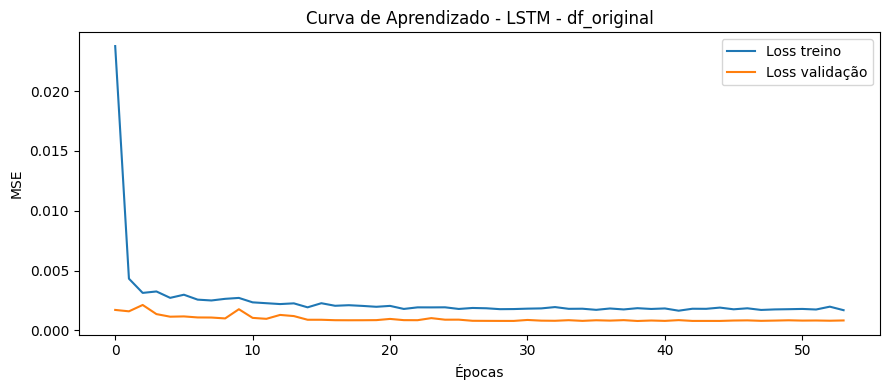


PROCESSANDO LSTM: DF_SEMANAL
Finalizado df_semanal | RMSE: 10.8810 | MAE: 8.4207 | R²: 0.7089 | MAPE: 4.27%


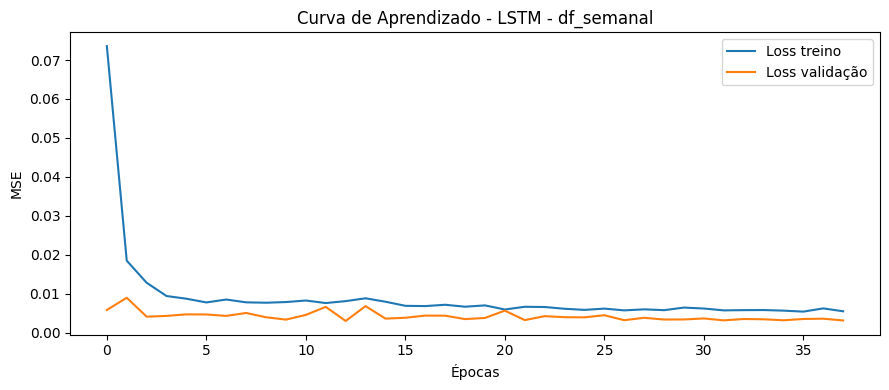


PROCESSANDO LSTM: DF_GERAL


Finalizado df_geral | RMSE: 6.5729 | MAE: 5.2399 | R²: 0.8908 | MAPE: 2.65%


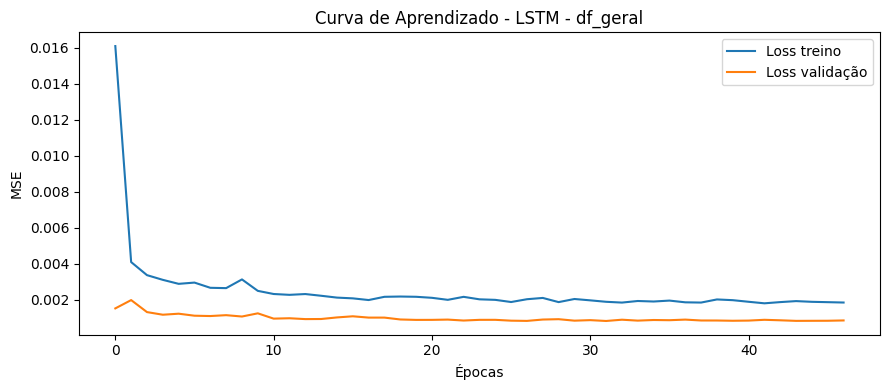


PROCESSANDO LSTM: DF_GERAL_SEMANAL
Finalizado df_geral_semanal | RMSE: 9.5337 | MAE: 7.2072 | R²: 0.7765 | MAPE: 3.62%


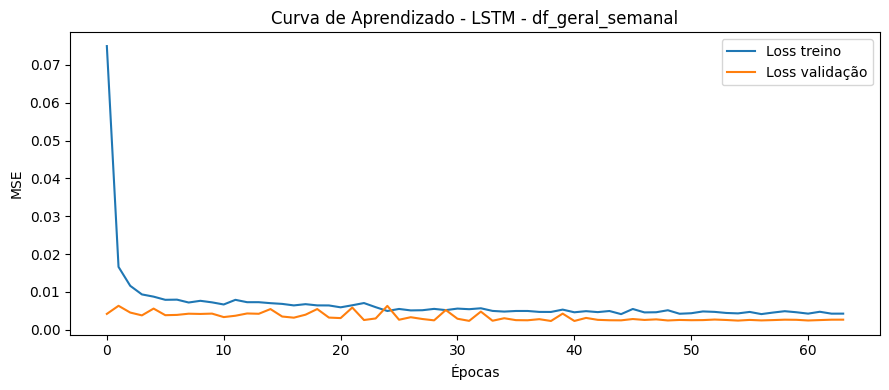


PROCESSANDO LSTM: DF_TOP10_CORR
Finalizado df_top10_corr | RMSE: 6.0378 | MAE: 4.7935 | R²: 0.9078 | MAPE: 2.42%


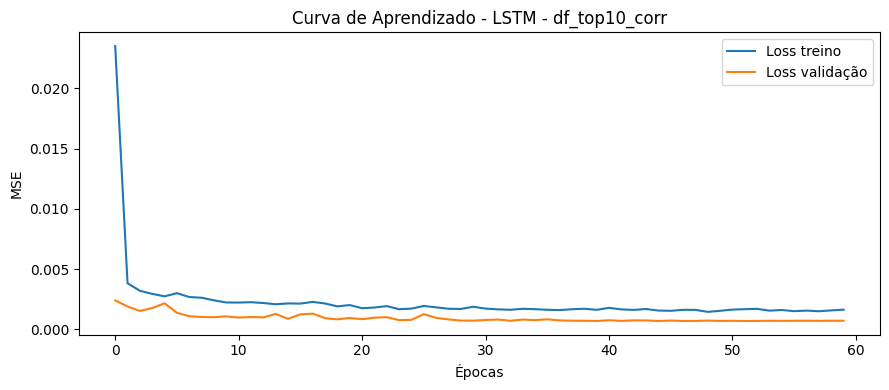

,Modelo,Dataset,Frequencia,n_steps,RMSE,MAE,R2,MAPE_%
df_top10_corr,LSTM,df_top10_corr,diario,30,6.037770,4.793477,0.907827,2.419891
df_original,LSTM,df_original,diario,30,6.191949,4.900683,0.903060,2.486552
df_geral,LSTM,df_geral,diario,30,6.572922,5.239894,0.890764,2.646526
df_geral_semanal,LSTM,df_geral_semanal,semanal,10,9.533693,7.207190,0.776521,3.621018
df_semanal,LSTM,df_semanal,semanal,10,10.880950,8.420711,0.708897,4.269112


In [ ]:
def executar_lstm_univariado(datasets):
    resumo_metricas_lstm = {}
    modelos_lstm = {}
    historico_previsoes_lstm = {}

    for nome, df_temp in datasets.items():
        print('\n' + '='*70)
        print(f'PROCESSANDO LSTM: {nome.upper()}')
        print('='*70)

        df_atual = df_temp.copy()
        df_atual['Date'] = pd.to_datetime(df_atual['Date'])
        df_atual = df_atual[df_atual['Date'] >= '2020-01-01'].reset_index(drop=True)

        if 'semanal' in nome:
            frequencia = 'semanal'
            n_steps = 10
            epochs = 200
            batch_size = 16
            units_l1, units_l2 = 64, 32
            patience_es, patience_lr = 25, 8
        else:
            frequencia = 'diario'
            n_steps = 30
            epochs = 100
            batch_size = 32
            units_l1, units_l2 = 100, 50
            patience_es, patience_lr = 15, 5

        precos_raw = df_atual['Close'].values.reshape(-1, 1)

        scaler = MinMaxScaler(feature_range=(0, 1))
        precos_scaled = scaler.fit_transform(precos_raw)

        split_idx = int(len(precos_scaled) * 0.80)

        train_data = precos_scaled[:split_idx]
        test_data = precos_scaled[split_idx:]

        X_train, y_train = [], []
        for i in range(len(train_data) - n_steps):
            X_train.append(train_data[i:(i + n_steps)])
            y_train.append(train_data[i + n_steps])

        X_test, y_test = [], []
        for i in range(len(test_data) - n_steps):
            X_test.append(test_data[i:(i + n_steps)])
            y_test.append(test_data[i + n_steps])

        X_train = np.array(X_train)
        y_train = np.array(y_train)

        X_test = np.array(X_test)
        y_test = np.array(y_test)

        model = Sequential([
            Input(shape=(n_steps, 1)),
            LSTM(units=units_l1, activation='tanh', return_sequences=True),
            Dropout(0.2 if frequencia == 'diario' else 0.1),
            LSTM(units=units_l2, activation='tanh'),
            Dropout(0.2 if frequencia == 'diario' else 0.1),
            Dense(units=1)
        ])

        model.compile(optimizer='adam', loss='mse')

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-6, verbose=0)
        ]

        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=0
        )

        y_pred_scaled = model.predict(X_test, verbose=0)

        y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
        y_pred_original = scaler.inverse_transform(y_pred_scaled)

        r2 = r2_score(y_test_original, y_pred_original)
        rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        mae = mean_absolute_error(y_test_original, y_pred_original)
        mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

        resumo_metricas_lstm[nome] = {
            'Modelo': 'LSTM',
            'Dataset': nome,
            'Frequencia': frequencia,
            'n_steps': n_steps,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'MAPE_%': mape
        }

        modelos_lstm[nome] = {
            'modelo': model,
            'scaler': scaler,
            'n_steps': n_steps,
            'frequencia': frequencia,
            'df_treino': df_atual,
            'history': history,
            'y_test': y_test_original.flatten(),
            'y_pred': y_pred_original.flatten()
        }

        historico_previsoes_lstm[nome] = y_pred_original.flatten()

        print(f'Finalizado {nome} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | MAPE: {mape:.2f}%')

        plt.figure(figsize=(9, 4))
        plt.plot(history.history['loss'], label='Loss treino')
        plt.plot(history.history['val_loss'], label='Loss validação')
        plt.title(f'Curva de Aprendizado - LSTM - {nome}')
        plt.xlabel('Épocas')
        plt.ylabel('MSE')
        plt.legend()
        plt.tight_layout()
        plt.show()

    df_lstm = pd.DataFrame(resumo_metricas_lstm).T.sort_values('RMSE')
    return df_lstm, modelos_lstm, historico_previsoes_lstm


df_resultados_lstm, modelos_lstm, historico_lstm = executar_lstm_univariado(datasets)

display(df_resultados_lstm)

In [ ]:
def prever_lstm_futuro(modelo_info, passos=1):
    modelo = modelo_info['modelo']
    scaler = modelo_info['scaler']
    n_steps = modelo_info['n_steps']
    df_base = modelo_info['df_treino']

    historico = df_base['Close'].values.astype(float).tolist()
    previsoes = []

    for _ in range(passos):
        janela = np.array(historico[-n_steps:]).reshape(-1, 1)
        janela_scaled = scaler.transform(janela).reshape(1, n_steps, 1)

        pred_scaled = modelo.predict(janela_scaled, verbose=0)[0][0]
        pred = float(scaler.inverse_transform([[pred_scaled]])[0][0])

        previsoes.append(pred)
        historico.append(pred)

    return previsoes


resultados_futuros_lstm = []

for nome, info in modelos_lstm.items():
    previsoes_90 = prever_lstm_futuro(info, passos=90)

    resultados_futuros_lstm.append({
        'Modelo': 'LSTM',
        'Dataset': nome,
        'Previsao_t1': previsoes_90[0],
        'Previsao_t90': previsoes_90[-1]
    })

df_previsoes_lstm = pd.DataFrame(resultados_futuros_lstm)

display(df_previsoes_lstm)

,Modelo,Dataset,Previsao_t1,Previsao_t90
0,LSTM,df_original,219.217386,171.324610
1,LSTM,df_semanal,232.490704,277.297176
2,LSTM,df_geral,218.091852,168.128572
3,LSTM,df_geral_semanal,228.377425,185.672926
4,LSTM,df_top10_corr,217.880306,164.984118


## 9. Modelagem — SVR

O SVR foi aplicado com variáveis defasadas (`lags=3`) e os hiperparâmetros definidos no projeto:

- `kernel = linear`
- `C = 1`
- `epsilon = 0.01`
- `gamma = scale`

A lógica foi organizada em função para evitar repetição, mantendo a ideia de criar atributos defasados e prever valores futuros de forma iterativa.

In [ ]:
def criar_dataset_lags(df_input, lags=3, target_col='Close'):
    df_temp = df_input.copy()

    if 'Date' in df_temp.columns:
        df_temp = df_temp.drop(columns=['Date'])

    df_temp = df_temp.select_dtypes(include=[np.number])
    df_temp = df_temp.replace([np.inf, -np.inf], np.nan)
    df_temp = df_temp.ffill().fillna(0)

    df_lags = pd.DataFrame(index=df_temp.index)

    for col in df_temp.columns:
        for i in range(1, lags + 1):
            df_lags[f'{col}_lag_{i}'] = df_temp[col].shift(i)

    df_lags['y'] = df_temp[target_col]
    df_lags = df_lags.dropna()

    X = df_lags.drop(columns=['y'])
    y = df_lags['y']

    return X, y


def preparar_df_svr(df_input):
    df_temp = df_input.copy()

    if 'Date' in df_temp.columns:
        df_temp['Date'] = pd.to_datetime(df_temp['Date'], errors='coerce')
        df_temp = df_temp.sort_values('Date').reset_index(drop=True)

    df_temp = df_temp.replace([np.inf, -np.inf], np.nan)
    df_temp = df_temp.ffill().fillna(0)

    return df_temp


def prever_svr_iterativo(modelo, scaler_X, scaler_y, df_input, X_cols, lags=3, passos=90):
    df_temp = preparar_df_svr(df_input)

    feature_cols = [col for col in df_temp.select_dtypes(include=[np.number]).columns]
    historico = df_temp[feature_cols].tail(lags).copy().to_dict(orient='records')

    previsoes = []

    for _ in range(passos):
        current_input = {}

        for col in feature_cols:
            for j in range(1, lags + 1):
                current_input[f'{col}_lag_{j}'] = historico[lags - j][col]

        X_last = pd.DataFrame([current_input])
        X_last = X_last.reindex(columns=X_cols, fill_value=0)

        X_last_scaled = scaler_X.transform(X_last)

        pred_scaled = modelo.predict(X_last_scaled)[0]
        pred = float(scaler_y.inverse_transform([[pred_scaled]])[0][0])

        previsoes.append(pred)

        novo_registro = historico[-1].copy()
        novo_registro['Close'] = pred

        historico.append(novo_registro)
        historico.pop(0)

    return previsoes


def executar_svr(datasets, lags=3):
    resultados = []
    artefatos = {}

    svr_params = {
        'C': 1,
        'epsilon': 0.01,
        'gamma': 'scale',
        'kernel': 'linear'
    }

    for nome, df_temp in datasets.items():
        print('\n' + '='*60)
        print(f'PROCESSANDO SVR: {nome}')
        print('='*60)

        df_svr = preparar_df_svr(df_temp)

        X_full, y_full = criar_dataset_lags(df_svr, lags=lags, target_col='Close')

        X_train, X_test, y_train, y_test = train_test_split(
            X_full,
            y_full,
            test_size=0.33,
            shuffle=False,
            random_state=42
        )

        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)

        y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
        y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

        modelo = SVR(**svr_params)
        modelo.fit(X_train_scaled, y_train_scaled)

        y_pred_scaled = modelo.predict(X_test_scaled)

        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        y_test_original = scaler_y.inverse_transform(y_test_scaled).flatten()

        rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
        mae = mean_absolute_error(y_test_original, y_pred)
        r2 = r2_score(y_test_original, y_pred)

        previsoes_90 = prever_svr_iterativo(
            modelo=modelo,
            scaler_X=scaler_X,
            scaler_y=scaler_y,
            df_input=df_svr,
            X_cols=X_full.columns,
            lags=lags,
            passos=90
        )

        resultado = {
            'Modelo': 'SVR',
            'Dataset': nome,
            'Lags': lags,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Previsao_t1': previsoes_90[0],
            'Previsao_t90': previsoes_90[-1],
            'Features': X_full.shape[1],
            'Linhas_usadas': len(X_full)
        }

        resultados.append(resultado)

        artefatos[nome] = {
            'modelo': modelo,
            'scaler_X': scaler_X,
            'scaler_y': scaler_y,
            'y_test': y_test_original,
            'y_pred': y_pred,
            'X_cols': X_full.columns
        }

        print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")
        print(f"Previsão t+1: {previsoes_90[0]:.4f} | Previsão t+90: {previsoes_90[-1]:.4f}")

    df_resultados_svr = pd.DataFrame(resultados).sort_values('RMSE').reset_index(drop=True)
    return df_resultados_svr, artefatos


df_resultados_svr, artefatos_svr = executar_svr(datasets, lags=3)

display(df_resultados_svr)


PROCESSANDO SVR: df_original
RMSE: 2.4949 | MAE: 1.6528 | R²: 0.9977
Previsão t+1: 217.2184 | Previsão t+90: 218.7897

PROCESSANDO SVR: df_semanal
RMSE: 4.5175 | MAE: 3.0436 | R²: 0.9924
Previsão t+1: 225.2120 | Previsão t+90: 227.8624

PROCESSANDO SVR: df_geral
RMSE: 2.6189 | MAE: 1.7383 | R²: 0.9975
Previsão t+1: 219.6700 | Previsão t+90: 222.3165

PROCESSANDO SVR: df_geral_semanal
RMSE: 4.5767 | MAE: 3.1227 | R²: 0.9922
Previsão t+1: 223.3166 | Previsão t+90: 224.6687

PROCESSANDO SVR: df_top10_corr
RMSE: 2.5568 | MAE: 1.6906 | R²: 0.9976
Previsão t+1: 218.4943 | Previsão t+90: 221.2729


,Modelo,Dataset,Lags,MAE,RMSE,R2,Previsao_t1,Previsao_t90,Features,Linhas_usadas
0,SVR,df_original,3,1.652763,2.494887,0.997693,217.218412,218.789712,21,6984
1,SVR,df_top10_corr,3,1.690578,2.556757,0.997577,218.494292,221.272870,33,6984
2,SVR,df_geral,3,1.738258,2.618944,0.997458,219.670024,222.316527,105,6984
3,SVR,df_semanal,3,3.043624,4.517506,0.992446,225.211998,227.862350,30,1447
4,SVR,df_geral_semanal,3,3.122706,4.576733,0.992247,223.316560,224.668671,105,1447


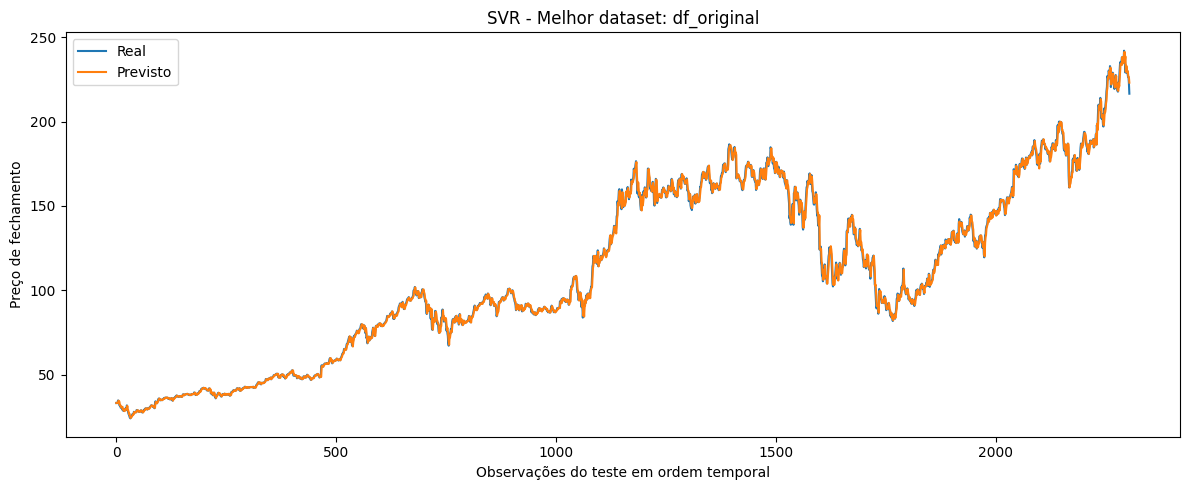

In [ ]:
melhor_svr = df_resultados_svr.iloc[0]['Dataset']

plt.figure(figsize=(12, 5))
plt.plot(artefatos_svr[melhor_svr]['y_test'], label='Real')
plt.plot(artefatos_svr[melhor_svr]['y_pred'], label='Previsto')
plt.title(f'SVR - Melhor dataset: {melhor_svr}')
plt.xlabel('Observações do teste em ordem temporal')
plt.ylabel('Preço de fechamento')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Validação externa com Yahoo Finance

A validação externa compara as previsões geradas a partir do último registro disponível no dataset com os valores reais obtidos no Yahoo Finance.

A última data do dataset é usada como referência.

In [ ]:
def buscar_preco_real_amzn(data_base, dias_futuro):
    data_base = pd.to_datetime(data_base)
    data_alvo = data_base + pd.Timedelta(days=dias_futuro)

    inicio = data_alvo.strftime('%Y-%m-%d')
    fim = (data_alvo + pd.Timedelta(days=15)).strftime('%Y-%m-%d')

    dados_yahoo = yf.download(
        TICKER_AMZN,
        start=inicio,
        end=fim,
        progress=False,
        auto_adjust=False
    )

    if dados_yahoo.empty:
        return None, None

    if isinstance(dados_yahoo.columns, pd.MultiIndex):
        preco_real = dados_yahoo['Close'].iloc[0, 0]
    else:
        preco_real = dados_yahoo['Close'].iloc[0]

    data_real = dados_yahoo.index[0]

    return data_real, float(preco_real)


ultima_data_dataset = datasets['df_geral']['Date'].max()

print(f'Última data disponível no dataset: {ultima_data_dataset.date()}')

data_real_d1, preco_real_d1 = buscar_preco_real_amzn(ultima_data_dataset, 1)
data_real_d90, preco_real_d90 = buscar_preco_real_amzn(ultima_data_dataset, 90)

print('Data real D1:', data_real_d1, 'Preço:', preco_real_d1)
print('Data real D90:', data_real_d90, 'Preço:', preco_real_d90)

Última data disponível no dataset: 2025-02-21
Data real D1: 2025-02-24 00:00:00 Preço: 212.7100067138672
Data real D90: 2025-05-22 00:00:00 Preço: 203.10000610351562


In [ ]:
def comparar_com_yahoo(nome_modelo, resultados_d1=None, resultados_d90=None, resultados_svr=None, resultados_lstm=None):
    linhas = []

    if resultados_svr is not None:
        melhor = resultados_svr.sort_values('RMSE').iloc[0]

        linhas.append({
            'Modelo': nome_modelo,
            'Horizonte': 'Próximo pregão',
            'Dataset_usado': melhor['Dataset'],
            'Data_real_comparada': data_real_d1,
            'Preco_previsto': melhor['Previsao_t1'],
            'Preco_real_yahoo': preco_real_d1
        })

        linhas.append({
            'Modelo': nome_modelo,
            'Horizonte': '90 dias',
            'Dataset_usado': melhor['Dataset'],
            'Data_real_comparada': data_real_d90,
            'Preco_previsto': melhor['Previsao_t90'],
            'Preco_real_yahoo': preco_real_d90
        })

    elif resultados_lstm is not None:
        # Usa o dataset com melhor RMSE no teste
        melhor_dataset = resultados_lstm.sort_values('RMSE').iloc[0]['Dataset']
        previsoes = df_previsoes_lstm[df_previsoes_lstm['Dataset'] == melhor_dataset].iloc[0]

        linhas.append({
            'Modelo': nome_modelo,
            'Horizonte': 'Próximo pregão',
            'Dataset_usado': melhor_dataset,
            'Data_real_comparada': data_real_d1,
            'Preco_previsto': previsoes['Previsao_t1'],
            'Preco_real_yahoo': preco_real_d1
        })

        linhas.append({
            'Modelo': nome_modelo,
            'Horizonte': '90 dias',
            'Dataset_usado': melhor_dataset,
            'Data_real_comparada': data_real_d90,
            'Preco_previsto': previsoes['Previsao_t90'],
            'Preco_real_yahoo': preco_real_d90
        })

    else:
        melhor_d1 = resultados_d1.sort_values('RMSE').iloc[0]
        melhor_d90 = resultados_d90.sort_values('RMSE').iloc[0]

        linhas.append({
            'Modelo': nome_modelo,
            'Horizonte': 'Próximo pregão',
            'Dataset_usado': melhor_d1['Dataset'],
            'Data_real_comparada': data_real_d1,
            'Preco_previsto': melhor_d1['Previsao_Futura'],
            'Preco_real_yahoo': preco_real_d1
        })

        linhas.append({
            'Modelo': nome_modelo,
            'Horizonte': '90 dias',
            'Dataset_usado': melhor_d90['Dataset'],
            'Data_real_comparada': data_real_d90,
            'Preco_previsto': melhor_d90['Previsao_Futura'],
            'Preco_real_yahoo': preco_real_d90
        })

    out = pd.DataFrame(linhas)

    out['Erro_absoluto'] = (out['Preco_real_yahoo'] - out['Preco_previsto']).abs()
    out['Erro_percentual_%'] = (out['Erro_absoluto'] / out['Preco_real_yahoo']) * 100

    return out


comparacao_lasso = comparar_com_yahoo(
    'Lasso',
    resultados_d1=df_resultados_lasso_d1,
    resultados_d90=df_resultados_lasso_d90
)

comparacao_ridge = comparar_com_yahoo(
    'Ridge',
    resultados_d1=df_resultados_ridge_d1,
    resultados_d90=df_resultados_ridge_d90
)

comparacao_svr = comparar_com_yahoo(
    'SVR',
    resultados_svr=df_resultados_svr
)

comparacao_lstm = comparar_com_yahoo(
    'LSTM',
    resultados_lstm=df_resultados_lstm
)

comparacao_yahoo = pd.concat(
    [comparacao_lasso, comparacao_ridge, comparacao_svr, comparacao_lstm],
    ignore_index=True
)

display(comparacao_yahoo)

,Modelo,Horizonte,Dataset_usado,Data_real_comparada,Preco_previsto,Preco_real_yahoo,Erro_absoluto,Erro_percentual_%
0,Lasso,Próximo pregão,df_top10_corr,2025-02-24,223.852128,212.710007,11.142122,5.238175
1,Lasso,90 dias,df_original,2025-05-22,202.453056,203.100006,0.646950,0.318538
2,Ridge,Próximo pregão,df_top10_corr,2025-02-24,224.792962,212.710007,12.082955,5.680483
3,Ridge,90 dias,df_original,2025-05-22,202.955164,203.100006,0.144842,0.071316
4,SVR,Próximo pregão,df_original,2025-02-24,217.218412,212.710007,4.508405,2.119508
5,SVR,90 dias,df_original,2025-05-22,218.789712,203.100006,15.689706,7.725114
6,LSTM,Próximo pregão,df_top10_corr,2025-02-24,217.880306,212.710007,5.170299,2.430680
7,LSTM,90 dias,df_top10_corr,2025-05-22,164.984118,203.100006,38.115888,18.767054


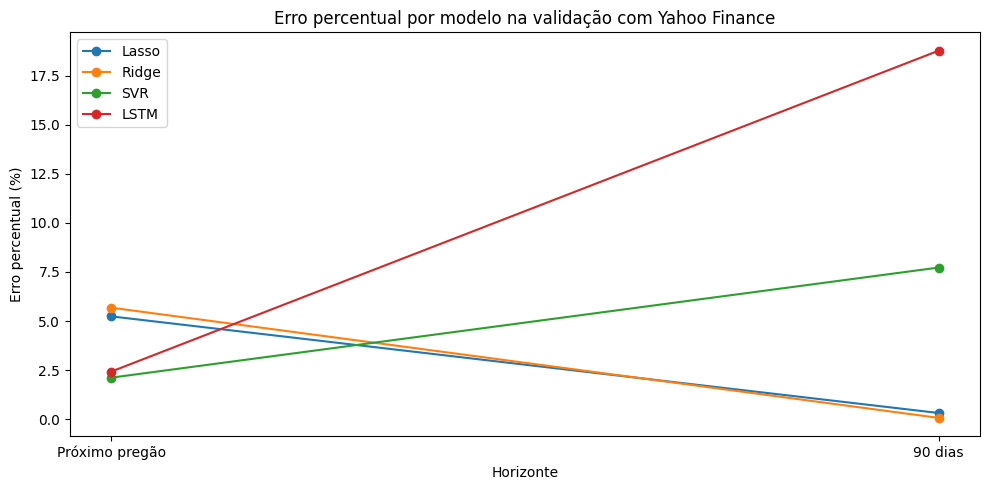

In [ ]:
plt.figure(figsize=(10, 5))

for modelo in comparacao_yahoo['Modelo'].unique():
    df_plot = comparacao_yahoo[comparacao_yahoo['Modelo'] == modelo]
    plt.plot(df_plot['Horizonte'], df_plot['Erro_percentual_%'], marker='o', label=modelo)

plt.title('Erro percentual por modelo na validação com Yahoo Finance')
plt.xlabel('Horizonte')
plt.ylabel('Erro percentual (%)')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Comparação final dos modelos

In [ ]:
# Padronização das tabelas de resultados para comparação geral
melhores_lasso = pd.concat([
    df_resultados_lasso_d1.assign(Horizonte_Label='t+1'),
    df_resultados_lasso_d90.assign(Horizonte_Label='t+90')
], ignore_index=True)

melhores_ridge = pd.concat([
    df_resultados_ridge_d1.assign(Horizonte_Label='t+1'),
    df_resultados_ridge_d90.assign(Horizonte_Label='t+90')
], ignore_index=True)

melhores_svr = df_resultados_svr.copy()
melhores_svr_t1 = melhores_svr.rename(columns={'Previsao_t1': 'Previsao_Futura'}).assign(Horizonte=1, Horizonte_Label='t+1')
melhores_svr_t90 = melhores_svr.rename(columns={'Previsao_t90': 'Previsao_Futura'}).assign(Horizonte=90, Horizonte_Label='t+90')
melhores_svr_comp = pd.concat([melhores_svr_t1, melhores_svr_t90], ignore_index=True)

df_lstm_comp = df_resultados_lstm.copy().reset_index(drop=True)
df_lstm_comp['Modelo'] = 'LSTM'
df_lstm_comp['Horizonte'] = 'teste'
df_lstm_comp['Horizonte_Label'] = 'teste'

comparativo_metricas = pd.concat([
    melhores_lasso[['Modelo', 'Dataset', 'Horizonte', 'Horizonte_Label', 'MAE', 'RMSE', 'R2']],
    melhores_ridge[['Modelo', 'Dataset', 'Horizonte', 'Horizonte_Label', 'MAE', 'RMSE', 'R2']],
    melhores_svr_comp[['Modelo', 'Dataset', 'Horizonte', 'Horizonte_Label', 'MAE', 'RMSE', 'R2']],
    df_lstm_comp[['Modelo', 'Dataset', 'Horizonte', 'Horizonte_Label', 'MAE', 'RMSE', 'R2']]
], ignore_index=True)

display(comparativo_metricas.sort_values(['Modelo', 'Horizonte_Label', 'RMSE']))

,Modelo,Dataset,Horizonte,Horizonte_Label,MAE,RMSE,R2
0,LASSO,df_top10_corr,1,t+1,2.385942,3.251299,0.992078
1,LASSO,df_original,1,t+1,2.401985,3.267375,0.991999
2,LASSO,df_geral,1,t+1,2.436919,3.325235,0.991675
3,LASSO,df_semanal,1,t+1,4.303103,5.717260,0.972942
4,LASSO,df_geral_semanal,1,t+1,4.300030,5.795262,0.974388
5,LASSO,df_original,90,t+90,20.790093,26.165059,0.478435
6,LASSO,df_geral,90,t+90,24.159877,31.893069,0.220614
7,LASSO,df_top10_corr,90,t+90,28.872251,36.851610,-0.034612
8,LASSO,df_geral_semanal,90,t+90,65.375113,86.504557,-5.404096
9,LASSO,df_semanal,90,t+90,124.133134,155.286842,-21.159134


## 12. Conclusões

- Os modelos lineares regularizados (**Lasso** e **Ridge**) foram avaliados em previsão futura com horizontes de `t+1` e `t+90`.
- O **Lasso** realiza seleção automática de atributos, zerando coeficientes pouco relevantes.
- O **Ridge** mantém todas as variáveis, apenas reduzindo a magnitude dos coeficientes.
- O **LSTM** foi aplicado como modelo recorrente univariado, usando janelas temporais do preço de fechamento.
- O **SVR** foi aplicado com defasagens (`lags`) para capturar dependência temporal da série.
- A validação externa com Yahoo Finance permite comparar a previsão gerada com valores reais posteriores ao dataset.

> Observação: modelos financeiros são sensíveis a volatilidade, notícias e eventos externos. Portanto, os resultados devem ser interpretados como estudo acadêmico de modelagem preditiva, não como recomendação de investimento.

## 13. Instruções para GitHub

Estrutura recomendada do repositório:

```text
amazon-stock-prediction/
├── ProjetoIntegrador_IV_GitHub_Completo.ipynb
├── datasets/
│   ├── AMZN_stock_data.csv
│   ├── df_original.csv
│   ├── df_semanal.csv
│   ├── df_geral.csv
│   ├── df_geral_semanal.csv
│   └── df_top10_corr.csv
├── README.md
└── requirements.txt
```

Sugestão de `requirements.txt`:

```text
pandas
numpy
matplotlib
scikit-learn
yfinance
kagglehub
tensorflow
```